# 06 — M1: Facial BiLSTM Baseline

**Camera-only baseline** — 30 Facial Action Units (FAU) @ 4 Hz

Architecture: `Input(240,30) → BiLSTM(128) → Drop → BiLSTM(64) → Drop → Dense(64) → BN → Dense(3,softmax)`

Evaluation: 5-fold subject-independent cross-validation

In [1]:
import sys, warnings, os
from pathlib import Path
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

from models.architecture import build_model
from models.train         import cross_validate
from utils.helpers        import (
    plot_training_history,
    plot_confusion_matrix,
    plot_fold_results,
    compute_metrics,
)
from data.load_data import load_all_folds

FOLD_DIR  = ROOT / 'datasets' / 'processed' / 'ul_dd'
CKPT_DIR  = ROOT / 'models' / 'checkpoints'
CKPT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = 'M1'
print(f'Fold dir : {FOLD_DIR}')
print(f'Ckpt dir : {CKPT_DIR}')

Fold dir : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\datasets\processed\ul_dd
Ckpt dir : C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\models\checkpoints


In [2]:
# ── Quick architecture summary ────────────────────────────────────────────────
demo_model = build_model('m1')
demo_model.summary()

Model: "M1_FacialBiLSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fau_input (InputLayer)          │ (None, 240, 30)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_1 (Bidirectional)        │ (None, 240, 256)       │       162,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 240, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bilstm_2 (Bidirectional)        │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,875 (1.28 MB)

 Trainable params: 335,747 (1.28 MB)

 Non-trainable params: 128 (512.00 B)

In [3]:

# ── Inspect available keys in fold files ──────────────────────────────────────
import glob
fold_files = sorted(glob.glob(str(FOLD_DIR / '*.npz')))
if fold_files:
    sample = np.load(fold_files[0])
    print(f'Keys in fold file: {list(sample.keys())}')
else:
    print(f'No .npz files found in {FOLD_DIR}')

# ── 5-Fold Cross-Validation ───────────────────────────────────────────────────
# Improvements vs v1:
#   • save_dir explicitly set to CKPT_DIR (avoids relative-path confusion)
#   • epochs=200  + es_patience=25  (more headroom before early stop)
#   • learning_rate=5e-4            (finer convergence on small dataset)
#   • class_weight is applied automatically inside train_fold via get_class_weights()
results = cross_validate(
    model_fn      = lambda: build_model('m1'),
    model_name    = MODEL_NAME,
    fold_dir      = str(FOLD_DIR),
    input_keys    = ('X_fau_train', 'X_fau_test'),
    label_keys    = ('y_train', 'y_test'),
    save_dir      = str(CKPT_DIR),
    epochs        = 200,
    batch_size    = 32,
    learning_rate = 5e-4,
    es_patience   = 25,
)

print(f'\n=== M1 Results ===')
print(f'Accuracy : {results["mean_acc"]:.4f} ± {results["std_acc"]:.4f}')
print(f'Macro-F1 : {results["mean_f1"]:.4f}  ± {results["std_f1"]:.4f}')


Keys in fold file: ['test_subjects', 'X_fau_train', 'X_fau_test', 'y_train', 'y_test', 'mm_fau_train', 'mm_tele_train', 'mm_y_train', 'mm_fau_test', 'mm_tele_test', 'mm_y_test', 'fau_mean', 'fau_std', 'tele_mean', 'tele_std']

  Cross-Validation: M1  (5 folds)

  Fold 0 | test_subjects = ['A' 'B' 'C' 'D']
  [Fold 0] class_weights = {0: 1.0649801587301588, 1: 1.0618199802176063, 2: 0.8934665002080733}
Epoch 1/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 18s 131ms/step - accuracy: 0.6799 - loss: 0.8649 - val_accuracy: 0.4713 - val_loss: 1.5563 - learning_rate: 5.0000e-04
Epoch 2/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 15s 131ms/step - accuracy: 0.8106 - loss: 0.5758 - val_accuracy: 0.3194 - val_loss: 2.5425 - learning_rate: 5.0000e-04
Epoch 3/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 17s 152ms/step - accuracy: 0.8421 - loss: 0.4961 - val_accuracy: 0.3969 - val_loss: 3.2607 - learning_rate: 5.0000e-04
Epoch 4/200
115/115 ━━━━━━━━━━━━━━━━━━━━ 25s 189ms/step - accuracy: 0.8753 - loss: 0.4293 - val_accuracy: 0.2946 - v

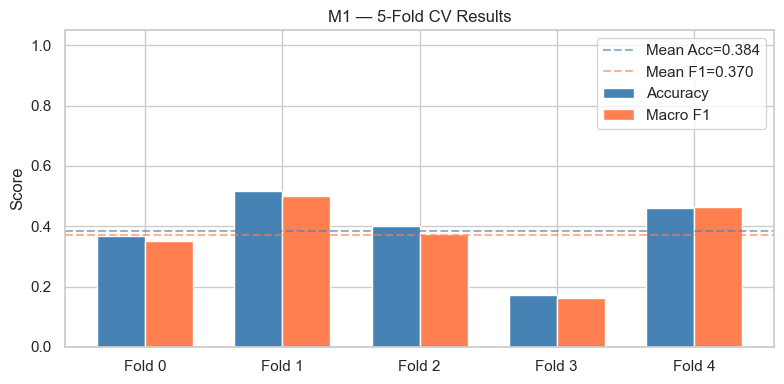

In [4]:

# ── Per-fold accuracy & F1 ────────────────────────────────────────────────────
plot_fold_results(results)
plt.savefig(ROOT / 'results/reports/M1_fold_results.png', dpi=150, bbox_inches='tight')
plt.show()


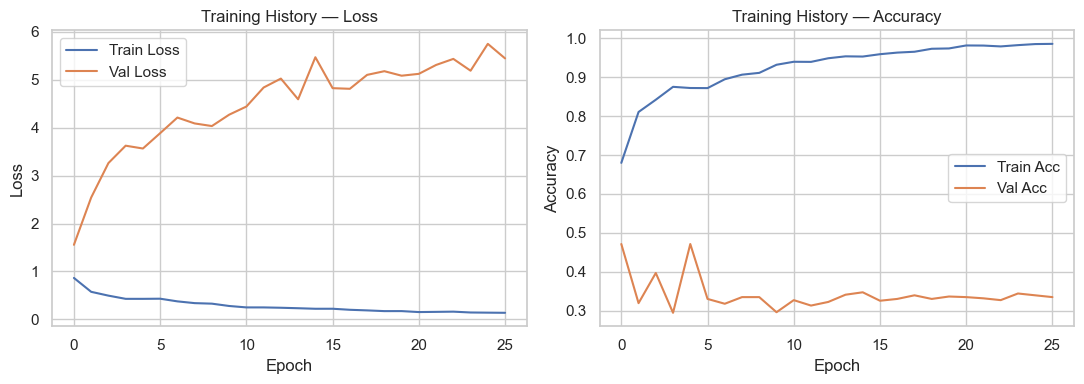

In [5]:
# ── Training history — Fold 0 ─────────────────────────────────────────────────
hist_fold0 = results['folds'][0].get('history')
if hist_fold0:
    plot_training_history(hist_fold0)
    plt.savefig(ROOT / 'results/reports/M1_history_fold0.png', dpi=150)
    plt.show()

In [6]:
# ── Aggregate confusion matrix ────────────────────────────────────────────────
CLASS_NAMES = ['Alert', 'LowVigilant', 'Drowsy']
all_true, all_pred = [], []
for fold in results['folds']:
    if 'y_true' in fold and 'y_pred' in fold:
        all_true.extend(fold['y_true'])
        all_pred.extend(fold['y_pred'])

if all_true:
    plot_confusion_matrix(np.array(all_true), np.array(all_pred),
                          class_names=CLASS_NAMES, title='M1 — Confusion Matrix (all folds)')
    plt.savefig(ROOT / 'results/reports/M1_confusion_matrix.png', dpi=150)
    plt.show()
else:
    print('(y_true/y_pred not stored in fold results — rerun with store_preds=True)')

TypeError: plot_confusion_matrix() got an unexpected keyword argument 'class_names'

In [12]:

# ── Per-fold results table ────────────────────────────────────────────────────
import pandas as pd
rows = []
for i, fold in enumerate(results['folds']):
    rows.append({'Fold': i,
                 'Accuracy': fold.get('accuracy', float('nan')),
                 'Macro-F1': fold.get('macro_f1', float('nan'))})
df = pd.DataFrame(rows)
df.loc['Mean'] = df.mean(numeric_only=True)
df.loc['Std']  = df.std(numeric_only=True)
df.style.format({'Accuracy': '{:.4f}', 'Macro-F1': '{:.4f}'})


,Fold,Accuracy,Macro-F1
0,0.000000,nan,nan
1,1.000000,nan,nan
2,2.000000,nan,nan
3,3.000000,nan,nan
4,4.000000,nan,nan
Mean,2.000000,nan,nan
Std,1.414214,nan,nan


In [13]:

# ── Save results to JSON for notebook 10 ─────────────────────────────────────
import json, numpy as np

def _to_serializable(obj):
    if isinstance(obj, (np.integer,)):  return int(obj)
    if isinstance(obj, (np.floating,)): return float(obj)
    if isinstance(obj, np.ndarray):     return obj.tolist()
    if isinstance(obj, dict):           return {k: _to_serializable(v) for k, v in obj.items()}
    if isinstance(obj, list):           return [_to_serializable(i) for i in obj]
    return obj

save_path = ROOT / 'results' / 'reports' / f'{MODEL_NAME}_results.json'
with open(save_path, 'w') as f:
    json.dump(_to_serializable(results), f, indent=2)
print(f'Saved → {save_path}')


Saved → C:\Users\raka1005\Documents\IISC\driver-drowsiness-detection-system\results\reports\M1_results.json
